In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from fastai import *
from fastai.vision import *

In [3]:
path = untar_data(URLs.PETS); path

PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet')

In [4]:
path.ls()

[PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/images'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/annotations')]

In [5]:
len((path/'images').ls()), len((path/'annotations').ls())

(7394, 7)

In [6]:
(path/'annotations').ls()

[PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/annotations/list.txt'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/annotations/trainval.txt'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/annotations/._trimaps'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/annotations/README'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/annotations/test.txt'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/annotations/trimaps'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/annotations/xmls')]

In [7]:
path_img = path/'images'

In [8]:
fnames = get_image_files(path_img)

In [9]:
fnames[:5]

[PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/images/leonberger_119.jpg'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/images/pomeranian_142.jpg'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/images/Bombay_88.jpg'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/images/yorkshire_terrier_5.jpg'),
 PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/images/basset_hound_137.jpg')]

In [10]:
np.random.seed(1989)

In [11]:
pat = re.compile(r'/([^/]+)_\d+.jpg$')

In [12]:
bs = 64
data = ImageDataBunch.from_name_re(path_img, fnames, pat, 
                                   ds_tfms=get_transforms(),size=224, bs=bs) 

In [13]:
data.classes

['leonberger',
 'pomeranian',
 'Bombay',
 'yorkshire_terrier',
 'basset_hound',
 'Sphynx',
 'newfoundland',
 'english_cocker_spaniel',
 'beagle',
 'english_setter',
 'american_pit_bull_terrier',
 'wheaten_terrier',
 'staffordshire_bull_terrier',
 'scottish_terrier',
 'Russian_Blue',
 'Egyptian_Mau',
 'Maine_Coon',
 'Bengal',
 'Siamese',
 'chihuahua',
 'great_pyrenees',
 'Ragdoll',
 'boxer',
 'german_shorthaired',
 'japanese_chin',
 'american_bulldog',
 'British_Shorthair',
 'Persian',
 'shiba_inu',
 'Birman',
 'keeshond',
 'miniature_pinscher',
 'saint_bernard',
 'Abyssinian',
 'samoyed',
 'havanese',
 'pug']

In [14]:
data.c==len(data.classes)

True

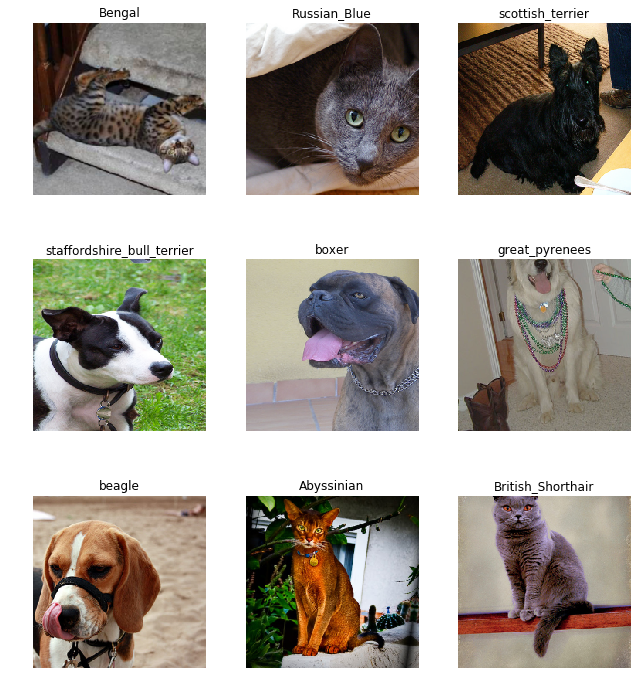

In [15]:
data.show_batch(3)

# Training: resnet34

In [16]:
learn = create_cnn(data, models.resnet34, metrics=error_rate)

In [17]:
learn.fit_one_cycle(4)

Total time: 02:09
epoch  train_loss  valid_loss  error_rate
1      1.202950    0.300699    0.096076    (00:34)
2      0.523751    0.254428    0.085927    (00:31)
3      0.312312    0.195767    0.062246    (00:31)
4      0.234776    0.191290    0.058863    (00:31)



In [18]:
learn.save('pet-prophet-stage1')

In [19]:
interp = ClassificationInterpretation.from_learner(learn)

In [20]:
interp.most_confused()

[('staffordshire_bull_terrier', 'american_pit_bull_terrier', 9),
 ('Ragdoll', 'Birman', 5),
 ('Egyptian_Mau', 'Bengal', 4),
 ('Persian', 'Ragdoll', 4),
 ('miniature_pinscher', 'chihuahua', 4),
 ('Bengal', 'Maine_Coon', 3),
 ('american_bulldog', 'american_pit_bull_terrier', 3),
 ('american_bulldog', 'staffordshire_bull_terrier', 3),
 ('yorkshire_terrier', 'havanese', 2),
 ('english_cocker_spaniel', 'english_setter', 2),
 ('beagle', 'basset_hound', 2),
 ('american_pit_bull_terrier', 'american_bulldog', 2)]

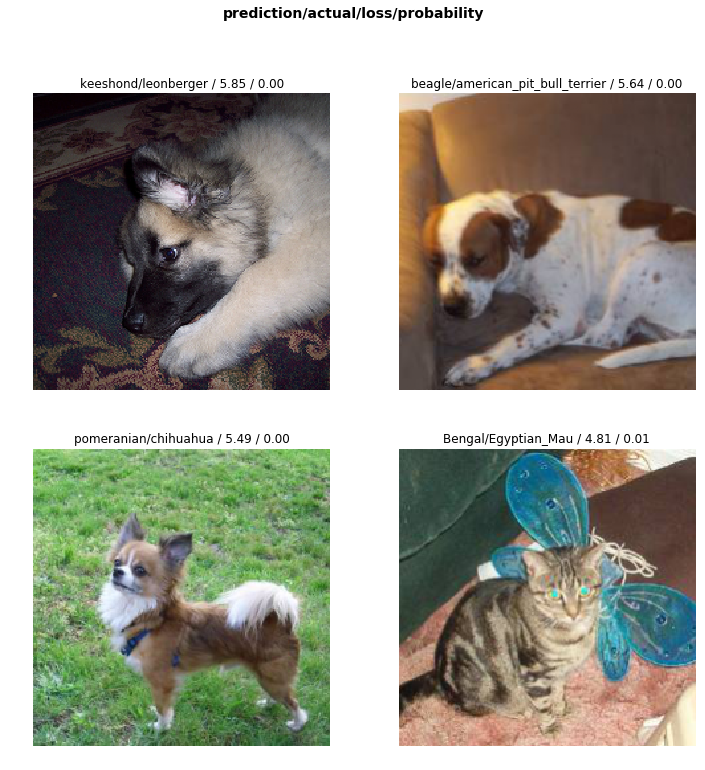

In [27]:
interp.plot_top_losses(4)

In [28]:
learn.lr_find()

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.


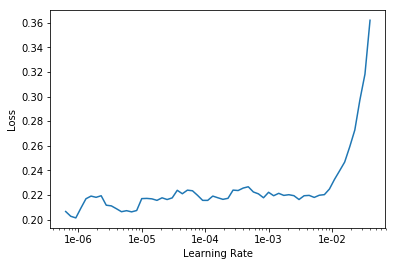

In [29]:
learn.recorder.plot()

In [30]:
learn.unfreeze()
learn.fit_one_cycle(4, max_lr=slice(1e-5,1e-4))

Total time: 02:44
epoch  train_loss  valid_loss  error_rate
1      0.209516    0.198474    0.063599    (00:40)
2      0.188904    0.185478    0.064953    (00:40)
3      0.165987    0.171979    0.054804    (00:41)
4      0.132903    0.175304    0.055480    (00:42)



In [31]:
learn.save('pet-prophet-stage2')

In [32]:
learn.lr_find()

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.


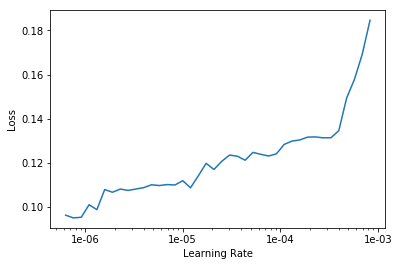

In [33]:
learn.recorder.plot()

In [34]:
learn.load('pet-prophet-stage2')

Learner(data=ImageDataBunch;
Train: LabelList
y: CategoryList (5912 items)
[Category leonberger, Category pomeranian, Category Bombay, Category yorkshire_terrier, Category basset_hound]...
Path: /home/jupyter/.fastai/data/oxford-iiit-pet/images
x: ImageItemList (5912 items)
[Image (3, 332, 500), Image (3, 225, 300), Image (3, 150, 200), Image (3, 375, 500), Image (3, 375, 500)]...
Path: /home/jupyter/.fastai/data/oxford-iiit-pet/images;
Valid: LabelList
y: CategoryList (1478 items)
[Category keeshond, Category Persian, Category newfoundland, Category boxer, Category Bengal]...
Path: /home/jupyter/.fastai/data/oxford-iiit-pet/images
x: ImageItemList (1478 items)
[Image (3, 375, 500), Image (3, 500, 386), Image (3, 333, 500), Image (3, 500, 375), Image (3, 387, 500)]...
Path: /home/jupyter/.fastai/data/oxford-iiit-pet/images;
Test: None, model=Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=

In [38]:
learn.path

PosixPath('/home/jupyter/.fastai/data/oxford-iiit-pet/images')

In [39]:
learn.model_dir

'models'

In [43]:
learn.model_dir

'models'

In [52]:
doc(create_cnn)

In [ ]:
path_img